<a href="https://colab.research.google.com/github/Yashlad041/Edunet-Intership-tasks-/blob/main/DAY-5_10-07-2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DAY 5
Task 1: Generalization, Analysis & Relationship Between Features

In [1]:
import pandas as pd

   Load Dataset
df = pd.read_csv("/content/energy_dataset.csv")

  Display basic information
print(df.head())
print(df.info())
print(df.describe())

 Check data types
print(df.dtypes)

  Find correlation between numerical columns
print(df.corr(numeric_only=True))


 Generalization & Analysis


The dataset contains electricity generation data from different energy sources.
 Each row represents energy production and market information for a specific date and time.
Renewable sources include solar, wind and hydro.
 Non-renewable sources include gas, coal and oil.
 Electricity price is influenced by demand and power generation.

 Relationships
 Wind generation depends on wind availability.
 Solar generation depends on sunlight.
 Higher energy demand generally increases electricity prices.
 Renewable and fossil fuel production together meet electricity demand.

                        time  generation biomass  \
0  2015-01-01 00:00:00+01:00               447.0   
1  2015-01-01 01:00:00+01:00               449.0   
2  2015-01-01 02:00:00+01:00               448.0   
3  2015-01-01 03:00:00+01:00               438.0   
4  2015-01-01 04:00:00+01:00               428.0   

   generation fossil brown coal/lignite  generation fossil coal-derived gas  \
0                                 329.0                                 0.0   
1                                 328.0                                 0.0   
2                                 323.0                                 0.0   
3                                 254.0                                 0.0   
4                                 187.0                                 0.0   

   generation fossil gas  generation fossil hard coal  generation fossil oil  \
0                 4844.0                       4821.0                  162.0   
1                 5196.0                       4755.

Task 2: Feature Engineering

In [3]:
import pandas as pd

df = pd.read_csv("/content/energy_dataset.csv")

# Convert datetime column into datetime format
df['time'] = pd.to_datetime(df['time'], utc=True)

# Create new features
df['Year'] = df['time'].dt.year
df['Month'] = df['time'].dt.month
df['Day'] = df['time'].dt.day
df['Hour'] = df['time'].dt.hour

print(df[['time','Year','Month','Day','Hour']].head())

                       time  Year  Month  Day  Hour
0 2014-12-31 23:00:00+00:00  2014     12   31    23
1 2015-01-01 00:00:00+00:00  2015      1    1     0
2 2015-01-01 01:00:00+00:00  2015      1    1     1
3 2015-01-01 02:00:00+00:00  2015      1    1     2
4 2015-01-01 03:00:00+00:00  2015      1    1     3


Task 3: Handle Null Values

In [4]:
import pandas as pd

df = pd.read_csv("/content/energy_dataset.csv")

# Check null values
print(df.isnull().sum())

# Fill numerical null values with mean
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical null values with mode
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

time                                               0
generation biomass                                19
generation fossil brown coal/lignite              18
generation fossil coal-derived gas                18
generation fossil gas                             18
generation fossil hard coal                       18
generation fossil oil                             19
generation fossil oil shale                       18
generation fossil peat                            18
generation geothermal                             18
generation hydro pumped storage aggregated     35064
generation hydro pumped storage consumption       19
generation hydro run-of-river and poundage        19
generation hydro water reservoir                  18
generation marine                                 19
generation nuclear                                17
generation other                                  18
generation other renewable                        18
generation solar                              

Task 4: Seaborn Visualization

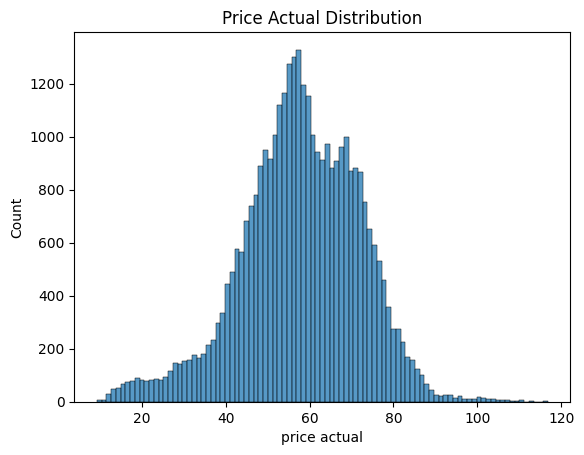

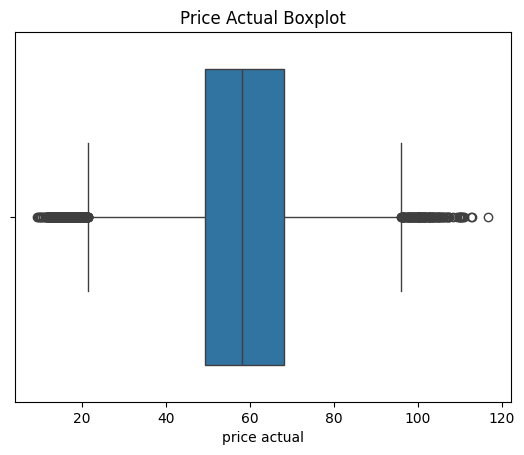

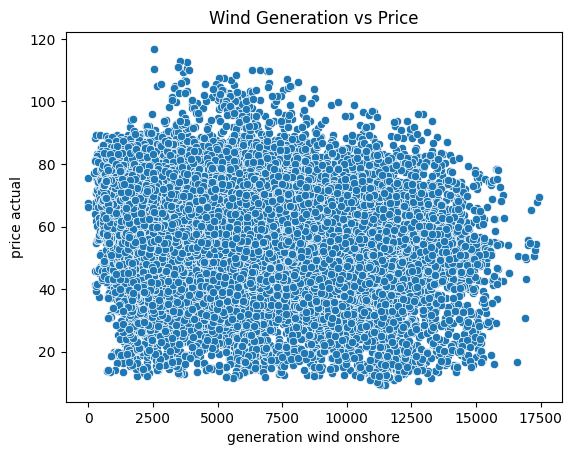

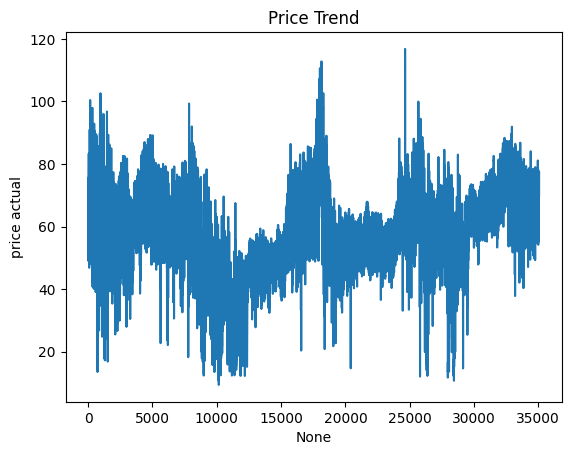

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("/content/energy_dataset.csv")

# 1. Histogram
sns.histplot(df['price actual'])
plt.title("Price Actual Distribution")
plt.show()

# 2. Boxplot
sns.boxplot(x=df['price actual'])
plt.title("Price Actual Boxplot")
plt.show()

# 3. Scatter Plot
sns.scatterplot(
    x='generation wind onshore',
    y='price actual',
    data=df
)
plt.title("Wind Generation vs Price")
plt.show()

# 4. Line Plot
sns.lineplot(
    x=df.index,
    y='price actual',
    data=df
)
plt.title("Price Trend")
plt.show()

Task 5: Scaling & Encoding

In [6]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("/content/energy_dataset.csv")

# ------------------------
# Scaling Numerical Columns
# ------------------------

scaler = StandardScaler()

num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

print(df.head())

# ------------------------
# Label Encoding
# ------------------------

label = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = label.fit_transform(df[col])

print(df.head())

# ------------------------
# One Hot Encoding
# ------------------------

dummy_df = pd.get_dummies(df)

print(dummy_df.head())

                        time  generation biomass  \
0  2015-01-01 00:00:00+01:00            0.743813   
1  2015-01-01 01:00:00+01:00            0.767245   
2  2015-01-01 02:00:00+01:00            0.755529   
3  2015-01-01 03:00:00+01:00            0.638368   
4  2015-01-01 04:00:00+01:00            0.521207   

   generation fossil brown coal/lignite  generation fossil coal-derived gas  \
0                             -0.335791                                 0.0   
1                             -0.338611                                 0.0   
2                             -0.352713                                 0.0   
3                             -0.547319                                 0.0   
4                             -0.736283                                 0.0   

   generation fossil gas  generation fossil hard coal  generation fossil oil  \
0              -0.353682                     0.288001              -2.595582   
1              -0.193813                     0.25435

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
